# Parameter selection for LADDIE

In [1]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
#import shapefile
#import shapely
#from cycler import cycler
#import geopandas as gpd

from parameter_selection_toolbox import *

#### Settings

In [2]:
# Directories
figure_dir = 'figures'
data_path="/home/erwin/data/ismip7/parameterisations/ocean"
ensemble_path="/home/erwin/projects/contrib-ismip/results/combined/"

# Constants
yearlen = 365.14*24*60*60 # seconds per year
ice_density = 918 # kg/m3
reso=4000 # m model resolution used for melt parameterisation [m]

# parameterisation ensemble table 
p1_name = 'Cdtop'
p2_name = 'dummy'

present_day_ensemble = "ensemble_laddie"


### Load data

In [3]:
# Load ensembles

pd_ensemble = xr.load_dataset(os.path.join(ensemble_path,'climatology.nc'))
mathiot_cold_ensemble = xr.load_dataset(os.path.join(ensemble_path,'Mathiot_NEMO_cold_v2.nc'))
mathiot_warm_ensemble = xr.load_dataset(os.path.join(ensemble_path,'Mathiot_NEMO_warm_v2.nc'))
naughten_cold_ensemble = xr.load_dataset(os.path.join(ensemble_path,'Naughten_FESOM_ACCESS_cold.nc'))
naughten_warm_ensemble = xr.load_dataset(os.path.join(ensemble_path,'Naughten_FESOM_ACCESS_warm.nc'))

In [4]:
# combine
cold_ensemble  = xr.concat([mathiot_cold_ensemble.expand_dims({"model": np.array([0])}), 
                            naughten_cold_ensemble.expand_dims({"model": np.array([1])})], dim='model')
cold_ensemble = cold_ensemble.assign_coords(model=["mathiot", "naughten"])

warm_ensemble  = xr.concat([mathiot_warm_ensemble.expand_dims({"model": np.array([0])}), 
                            naughten_warm_ensemble.expand_dims({"model": np.array([1])})], dim='model')
warm_ensemble = warm_ensemble.assign_coords(model=["mathiot", "naughten"])

In [5]:
years = np.array([1994,2000,2006,2007,2009,2010,2011,2012,2014,2016,2018,2019,2020])

datasets = []

print("Loading datasets...")
for i, yy in enumerate(years):
    filepath = os.path.join(ensemble_path, f'Dutrieux_{yy}.nc')
    
    # 1. Load the dataset
    ds = xr.load_dataset(filepath)
    
    # 2. Add the year dimension immediately
    # We use a scalar array to create a new dimension 'year' with value i (index)
    # Note: We use 'i' (0, 1, 2...) for the dimension index, then rename later
    ds_expanded = ds.expand_dims({"year": [i]})
    
    datasets.append(ds_expanded)
    
    # Optional: Clear memory if you have many files
    del ds, ds_expanded 
    if i % 5 == 0:
        gc.collect()

print("Concatenating...")
# 3. Concatenate ALL at once (O(N) memory, not O(N^2))
obs_ensemble = xr.concat(datasets, dim="year")

# 4. Assign the actual year values (1994, 2000...) as coordinates
# This maps the index 0->1994, 1->2000, etc.
obs_ensemble = obs_ensemble.assign_coords(year=("year", years))

# Optional: Clean up the list to free memory immediately
del datasets
gc.collect()

# Mask northern shelf
obs_ensemble = obs_ensemble.where(obs_ensemble.x>-1.625e6, other=0)

Loading datasets...
Concatenating...


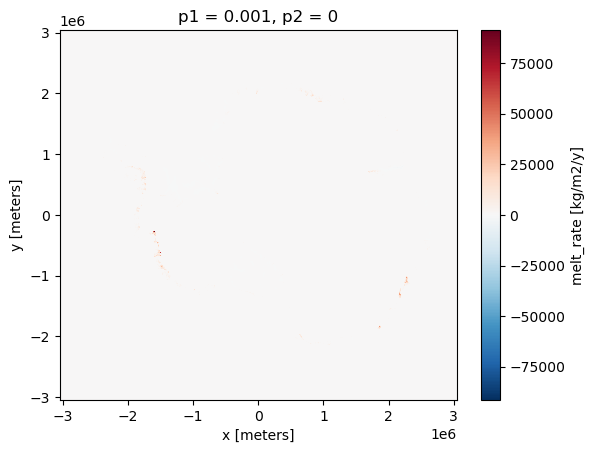

In [6]:
pd_ensemble.sel(p1=0.001).isel(p2=0).melt_rate.plot()

### Load target data

In [7]:
MeltDataImbieP = pd.read_csv(os.path.join(data_path,'meltobs','Melt_Paolo_Err_Adusumilli_imbie2_v3.csv'), index_col=0) # Aggregated per imbier basin
MeltDataImbieD = pd.read_csv(os.path.join(data_path, 'meltobs','Melt_Davison_imbie2.csv'), index_col=0) # Aggregated per imbier basin

buttressing_target = xr.load_dataset(os.path.join(data_path,'meltobs',"melt_target_term2.nc"))

cold_target = xr.load_dataset(os.path.join(data_path,'ocean_modelling_data',"melt_cold_target_term3.nc"))
warm_target = xr.load_dataset(os.path.join(data_path,'ocean_modelling_data',"melt_warm_target_term3.nc"))

t4_obs = xr.load_dataset(os.path.join(data_path,'ocean_observations_data', "melt_observations_target_term4.nc"))

In [8]:
# Supporting Data

# Load imbie2 basins as used on ISMIP
basins_m = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip4km_v2.nc"))
basins_m = basins_m.rename({'basinNumber':'basins'})
nBasins = int(basins_m.basins.max())

# Buttressing Flux Response Numbers, remapped to 8km 
bfrn_m = xr.load_dataset(os.path.join(data_path,'bfrns',"BFRN_ismip4km_v2.nc"))
nBins = 10

#Get floating mask
floatingmask = xr.load_dataset(os.path.join(data_path, 'floatingmasks', 'floatingmask_ismip4km.nc'))
mask_m = floatingmask.mask>0.5

In [9]:
# Ice shelf masks for PIG and Dotson for term 4
ds = xr.load_dataset(os.path.join(data_path, "shelfmask", "shelf_mask_ismip8km.nc"))
shelves = ds.shelf_mask.isel(time=0)
pig_id = 110
dis_id = 97
pig = (shelves==pig_id)
dotson = (shelves==dis_id)
pigdotson_mask = pig.astype(int) + dotson.astype(int) * 2
label_map = {1: "pig", 2: "dotson"}
labels = np.vectorize(label_map.get)(pigdotson_mask.values)
region_label = xr.DataArray(labels, dims=pigdotson_mask.dims, coords=pigdotson_mask.coords)
# Interpolate to model resolution
pigdotson_mask_m = pigdotson_mask.interp_like(bfrn_m,method='nearest')
#pigdotson_mask_m = pigdotson_mask.interp(method='nearest')
labels = np.vectorize(label_map.get)(pigdotson_mask_m.values)
region_label_m = xr.DataArray(labels, dims=pigdotson_mask_m.dims, coords=pigdotson_mask_m.coords)


### Optimise

In [10]:
cvt_m = reso**2  / 1e12  # to convert to Gt/a
cvt = 8000**2  / 1e12  # to convert to Gt/a

In [11]:
# Term 1
t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
    pd_ensemble,mask_m,basins_m['basins'],nBasins,cvt_m,MeltDataImbieP,MeltDataImbieD)

In [12]:
# Term 2
t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble,mask_m,bfrn_m,cvt_m,buttressing_target)

In [13]:
# Term 3
t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_ensemble, warm_ensemble, cold_target, warm_target,
    mask_m,basins_m['basins'])

In [14]:
# Term 4
t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(obs_ensemble, region_label_m, t4_obs, mask_m, cvt_m)

### Introduce weights

In [15]:
t1_weights = xr.DataArray(
    t1_obs_mean.isel(source=0)*0+1,
    dims=["basins"],
    coords={"basins": t1_model.basins.values}
)

In [16]:
# Buttressing Flux Response Numbers, remapped to 8km 
bfrn = xr.load_dataset(os.path.join(data_path, 'bfrns',"BFRN_ismip8km_v2.nc"))

t2_weight = (bfrn['BFRN_medians'] / bfrn['BFRN_median']).values

t2_weights = xr.DataArray(
    t2_weight,
    dims=["BFRN_bins"],
    coords={"BFRN_bins": t2_obs_mean.BFRN_bins.values}
)

In [17]:
weights_data = np.ones(t3_model.isel(p1=0,p2=0).shape) 

t3_weights = xr.DataArray(
    weights_data,
    dims=["model", "basins"],
    coords={"model": t3_model.model.values,
            "basins": t3_model.basins.values}
)

# only use mathiot
t3_weights = t3_weights.where((t3_weights.model == "mathiot"), other=0)


In [18]:
weights_data = np.transpose(np.ones(t4_obs.melt_rate.shape))

t4_weights = xr.DataArray(
    weights_data,
    dims=["year", "region"],
    coords={"year": t4_obs.year.values,
            "region": t4_obs.region.values}
)

# Only sample PIG in 2009 and 2012
t4_weights = t4_weights.where(t4_weights.region == "pig", other=0)
t4_weights = t4_weights.where((t4_weights.year ==2009) | (t4_weights.year==2012)  ,other=0)

In [19]:
sample_size=10000

min_p1, min_p2 = calculate_objective_function(
    sample_size,
    reso,
    t1_model, t1_obs_mean, t1_obs_sigma,t1_weights,
    t2_model, t2_obs_mean, t2_obs_sigma,t2_weights,
    t3_model, t3_obs_mean, t3_obs_sigma,t3_weights,
    t4_model, t4_obs_mean, t4_obs_sigma,t4_weights)

### Analyse parameter distribution

In [20]:
percentiles = [5,95]

Cd_md = np.median(min_p1)
Cd_lo = np.percentile(min_p1,percentiles[0])
Cd_hi = np.percentile(min_p1,percentiles[1])

print(f'median: {Cd_md}')
print(f'{percentiles[0]}th   : {Cd_lo}')
print(f'{percentiles[1]}th  : {Cd_hi}')


vals = [Cd_lo,Cd_md,Cd_hi]
labs = ['5th', '50th', '95th']

median: 0.0008
5th   : 0.0005
95th  : 0.0012000000000000001


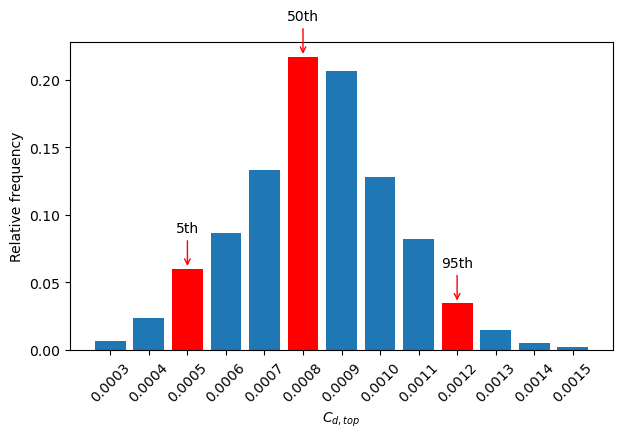

In [21]:
p1 = np.array(pd_ensemble.p1)
bin_edges = np.append(p1[0]-(p1[1]-p1[0])*.5,(p1[1:]+p1[:-1])*.5)
bin_edges = np.append(bin_edges,p1[-1]+(p1[-1]-p1[-2])*.5)

labels = [f'{p:.04f}' for p in p1]
fig,axes = plt.subplots(1,1,figsize=(7,4))

ax = axes
counts, _ = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(counts))
ax.bar(positions, counts/sample_size, width=0.8)

for i,val in enumerate(vals):
    bin_index = np.digitize(val, bin_edges) - 1
    ax.patches[bin_index].set_facecolor('red')
    bin_center = bin_index #(bin_edges[bin_index] + bin_edges[bin_index+1]) / 2
    plt.annotate(labs[i], xy=(bin_center, counts[bin_index]/sample_size), 
                 xytext=(bin_center, (counts[bin_index]+300)/sample_size),
                 ha='center', va='center',
                 arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xticks(positions, labels, rotation=45)
ax.set_xlabel('$C_{d,top}$');
ax.set_ylabel('Relative frequency');


### Analyse parameters

In [22]:
def get_t1(Cdval):
    t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
        pd_ensemble.sel(p1=Cdval).isel(p2=0), mask_m, basins_m.basins, nBasins, cvt_m, MeltDataImbieP,MeltDataImbieD)
    return t1_model, t1_obs_mean, t1_obs_sigma

def get_t2(Cdval):
    t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
        pd_ensemble.sel(p1=Cdval).isel(p2=0),mask_m,bfrn_m,cvt_m,buttressing_target)
    return t2_model, t2_obs_mean, t2_obs_sigma

def get_t3(Cdval):
    t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
        cold_ensemble.sel(p1=Cdval).isel(p2=0), warm_ensemble.sel(p1=Cdval).isel(p2=0), 
        cold_target, warm_target, mask_m, basins_m.basins)

    t3_stack = t3_model.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')
    return t3_stack, t3_obs_mean, t3_obs_sigma

def get_t4(Cdval):
    t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(
        obs_ensemble.sel(p1=Cdval).isel(p2=0), region_label_m, t4_obs, mask_m, cvt_m)

    t4_stack = t4_model.stack(region_year=("region", "year")).dropna(dim='region_year')
    return t4_stack, t4_obs_mean, t4_obs_sigma

Text(0.5, 1.0, 'Term 4')

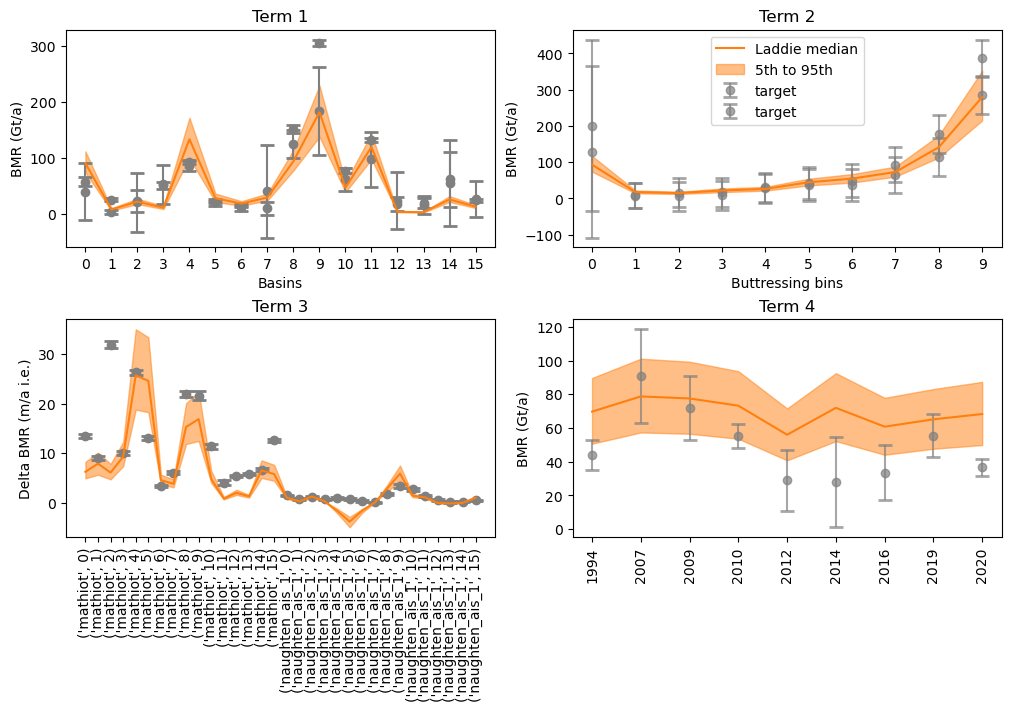

In [23]:
col = 'tab:orange'
label = 'Laddie median'
label2 = f'{percentiles[0]}th to {percentiles[1]}th'

fig, axes = plt.subplots(2,2, figsize=(10,7),constrained_layout=True)

# Term 1
ax = axes[0,0]

t1_md, t1_obs_mean, t1_obs_sigma = get_t1(Cd_md)
t1_lo, t1_obs_mean, t1_obs_sigma = get_t1(Cd_lo)
t1_hi, t1_obs_mean, t1_obs_sigma = get_t1(Cd_hi)

ax.plot(range(nBasins+1),t1_md , label=label, color=col,zorder=10)
ax.fill_between(range(nBasins+1),t1_lo,t1_hi , label=label2, color=col,alpha=.5)

for source in t1_obs_mean.source:
        ax.errorbar(range(nBasins+1), t1_obs_mean.sel(source=source), xerr=None, yerr=t1_obs_sigma.sel(source=source), 
             fmt='o', capsize=5, capthick=2, color=".5", 
             ecolor=".5", label='target')

ax.set_xticks(range(nBasins+1))
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Basins')
ax.set_title('Term 1')

# Term 2
ax = axes[0,1]

t2_md, t2_obs_mean, t2_obs_sigma = get_t2(Cd_md)
t2_lo, t2_obs_mean, t2_obs_sigma = get_t2(Cd_lo)
t2_hi, t2_obs_mean, t2_obs_sigma = get_t2(Cd_hi)

ax.plot(range(len(t2_md.BFRN_bins)),t2_md , label=label, color=col,zorder=10)
ax.fill_between(range(len(t2_md.BFRN_bins)),t2_lo,t2_hi , label=label2, color=col,alpha=.5)

for source in t2_obs_mean.source:
        ax.errorbar(range(len(t2_model.BFRN_bins)), t2_obs_mean.sel(source=source), xerr=None, yerr=t2_obs_sigma.sel(source=source), 
             fmt='o', capsize=5, capthick=2, color='.5',
             ecolor='.5', alpha=0.7, label='target')

ax.set_xticks(range(len(t2_model.BFRN_bins)))
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Buttressing bins')
ax.legend()
ax.set_title('Term 2')

# Term 3
ax = axes[1,0]  

t3_md, t3_obs_mean, t3_obs_sigma = get_t3(Cd_md)
t3_lo, t3_obs_mean, t3_obs_sigma = get_t3(Cd_lo)
t3_hi, t3_obs_mean, t3_obs_sigma = get_t3(Cd_hi)

ax.plot(range(len(t3_md.modelbasin)),
        t3_md/ice_density , label=label, color='tab:orange',zorder=10)
ax.fill_between(range(len(t3_md.modelbasin)),t3_lo/ice_density,t3_hi/ice_density, label=label2, color=col,alpha=.5)

t3_obs_mean = t3_obs_mean.sel(model=['mathiot','naughten_ais_1'])
t3_obs_sigma = t3_obs_sigma.sel(model=['mathiot','naughten_ais_1'])

ax.errorbar(range(len(t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin)), 
            t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
            xerr=None, yerr=t3_obs_sigma.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
             fmt='o', capsize=5, capthick=2, color='.5',
             ecolor='.5', label='target')

ax.set_ylabel('Delta BMR (m/a i.e.)')
ax.set_xticks(range(len(t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin)))
ax.set_xticklabels(t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin.values, rotation=90)
ax.set_title('Term 3')

# Term 4
ax = axes[1,1]

t4_md, t4_obs_mean, t4_obs_sigma = get_t4(Cd_md)
t4_lo, t4_obs_mean, t4_obs_sigma = get_t4(Cd_lo)
t4_hi, t4_obs_mean, t4_obs_sigma = get_t4(Cd_hi)

ax.plot(range(len(t4_md.region_year)),t4_md.values , label='Laddie', color='tab:orange',zorder=10)
ax.fill_between(range(len(t4_md.region_year)),t4_lo,t4_hi, label=label2, color=col,alpha=.5)

t4_obs_mean = t4_obs_mean.sel(region='pig').dropna(dim='year')
t4_obs_sigma = t4_obs_sigma.sel(region='pig').dropna(dim='year')

ax.errorbar(range(len(t4_obs_mean.year)), 
            t4_obs_mean, 
            xerr=None, 
            yerr=t4_obs_sigma,
             fmt='o', capsize=5, capthick=2, color='.5',
             ecolor='.5', alpha=0.7, label='target')

ax.set_ylabel('BMR (Gt/a)')
ax.set_xticks(range(len(t4_obs_mean.year)))
ax.set_xticklabels(t4_obs_mean.year.values, rotation=90)
ax.set_title('Term 4')